# `lated` quickstart — photometric emission-line recovery

`lated` fits a **transparent spectral model** through real filter transmission curves to recover
emission-line fluxes, rest-frame equivalent widths, and line ratios (with honest upper/lower
limits) from broad/medium-band photometry:

$$ f_\lambda(\lambda) \;=\; C\,(\lambda/\lambda_0)^{\beta} \;+\; \sum_l F_l\,\delta\!\left(\lambda - \lambda_l(1+z)\right) $$

Every parameter has an **explicit role**:

| parameter | default role |
|---|---|
| $C$ (continuum amplitude) | free ($\geq 0$) |
| $\beta$ (continuum slope) | free (grid-searched) *or* fixed (e.g. $-2$ in the three-band mode) |
| $z$ | fixed (e.g. from a Ly$\alpha$ slice), optional Gaussian $\sigma_z$ |
| $A_V$ | fixed ($0 \pm 0.01$ by default, propagated through the Monte-Carlo) |
| $F(\mathrm{H}\alpha)$, $F([\mathrm{O\,III}]\,5007)$ | free |
| H$\beta$, H$\gamma$…H10, $[\mathrm{O\,III}]\,4959$ | tied (Case A/B ratios, editable) |
| other lines | off (switchable) |

Install with `pip install lated`. This notebook walks through the Python API; the same engine
also powers a web application (`lated serve`) and a CLI (`lated fit`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import lated
from lated import FitConfig, fit, default_filters, model_spectrum

print("lated", lated.__version__)

/Users/mingyu/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


lated 0.1.0


## 1. The default line registry

The model's lines, their vacuum rest wavelengths, and their roles are all data you can inspect
and edit. `free` amplitudes are fit (non-negative), `tied` lines ride on their root at an
editable ratio (Case B at $T_e = 10^4$ K by default), and `off` lines are excluded.

In [2]:
for l in lated.default_lines():
    tie = f"  =  {l.ratio:.4f} x {l.tied_to}" if l.role == "tied" else ""
    print(f"{l.name:11s} {l.rest_wave:9.2f} A   {l.role:4s}{tie}")

Halpha        6564.61 A   free
Hbeta         4862.68 A   tied  =  0.3497 x Halpha
Hgamma        4341.68 A   tied  =  0.4680 x Hbeta
Hdelta        4102.89 A   tied  =  0.2590 x Hbeta
Hepsilon      3971.20 A   tied  =  0.1590 x Hbeta
H8            3890.15 A   tied  =  0.1050 x Hbeta
H9            3836.48 A   tied  =  0.0731 x Hbeta
H10           3798.98 A   tied  =  0.0530 x Hbeta
OIII5007      5008.24 A   free
OIII4959      4960.30 A   tied  =  0.3356 x OIII5007
HeII4686      4686.99 A   off 
OII3727       3728.48 A   off 
NeIII3869     3869.86 A   off 
HeI10830     10833.30 A   off 
NII6584       6585.27 A   off 
SII6717       6718.29 A   off 
SII6731       6732.67 A   off 


## 2. A three-band fit: the metal-free candidate CR3

CR3 ($z = 3.193$; Cai et al. 2025) is a spectroscopic Pop III candidate with
[O III]/H$\beta$ $< 0.89$. We fit its published photometry in the three LATED Wz3.1
selection bands with the slope fixed at $\beta = -2$ (the paper's three-band mode).

Photometry goes in as `{band: (flux_uJy, err_uJy)}`; the published values are in nJy.

In [3]:
NJY = 1e-3   # nJy -> uJy

phot_cr3 = {"F200W": (13.6 * NJY, 1.9 * NJY),
            "F277W": (24.9 * NJY, 1.6 * NJY),
            "F356W": (4.0 * NJY, 1.4 * NJY)}

cfg = FitConfig.fixed_slope(z=3.193)          # slope fixed at -2, sigma_beta = 0.3
res = fit(phot_cr3, cfg)

r3 = res.ratios[0]
print(f"status : {r3.status}")
print(f"R3     : < {r3.value.percentiles.p975:.2f}  (2-sigma) ;  < {r3.value.percentiles.p84:.2f}  (1-sigma)")
print(f"chi2   : {res.chi2:.3g}  (ndof = {res.ndof})")

status : upper_limit
R3     : < 0.73  (2-sigma) ;  < 0.48  (1-sigma)
chi2   : 0  (ndof = 0)


The ratio comes back with an explicit **status** — `measured`, `upper_limit`,
`lower_limit`, or `unconstrained` — instead of a bare number. Here the data support only a
2σ upper limit, deep in the metal-poor regime and consistent with the spectroscopy.

Every enabled line is reported, tied lines included, with fluxes, formal $1\sigma$ depths, and
rest-frame equivalent widths:

In [4]:
print(f"{'line':11s} {'role':5s} {'flux [erg/s/cm2]':>18s} {'16-84%':>24s} {'EW0 [A]':>9s}")
for l in res.lines:
    p = l.flux.percentiles
    ew = f"{l.ew0_rest:9.0f}" if l.ew0_rest is not None else "        -"
    print(f"{l.name:11s} {l.role:5s} {l.flux.best:18.3e} "
          f"{p.p16:11.2e} - {p.p84:9.2e} {ew}")

line        role    flux [erg/s/cm2]                   16-84%   EW0 [A]
Halpha      free           5.694e-18    5.13e-18 -  6.34e-18      8580
Hbeta       tied           1.991e-18    1.80e-18 -  2.22e-18      1646
Hgamma      tied           9.318e-19    8.40e-19 -  1.04e-18       614
Hdelta      tied           5.157e-19    4.65e-19 -  5.74e-19       304
Hepsilon    tied           3.166e-19    2.85e-19 -  3.52e-19       175
H8          tied           2.090e-19    1.88e-19 -  2.33e-19       111
H9          tied           1.455e-19    1.31e-19 -  1.62e-19        75
H10         tied           1.055e-19    9.51e-20 -  1.17e-19        53
OIII5007    free           3.777e-19    1.58e-19 -  9.70e-19       331
OIII4959    tied           1.268e-19    5.31e-20 -  3.25e-19       109


## 3. The SED view

`model_spectrum` reconstructs the best-fit model as $f_\nu$ for plotting, and
`band_model_uJy` holds the model integrated back through each band — the numbers the fit
actually compared to your photometry.

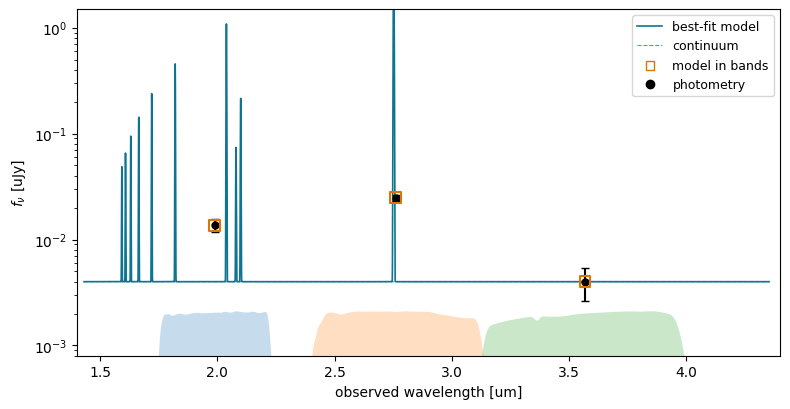

In [5]:
filters = default_filters()
lam, total, cont = model_spectrum(res)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(lam / 1e4, total, color="#0e7490", lw=1.2, label="best-fit model")
ax.plot(lam / 1e4, cont, color="#0e7490", lw=0.8, ls="--", alpha=0.7, label="continuum")

for b, (f, e) in phot_cr3.items():
    piv = filters[b].pivot / 1e4
    ax.errorbar(piv, f, yerr=e, fmt="o", color="k", ms=5, capsize=3, zorder=5)
    ax.scatter(piv, res.band_model_uJy[b], marker="s", s=60, facecolor="none",
               edgecolor="#d97706", lw=1.5, zorder=6)
    # filter curve along the floor
    w, t = filters[b].wave / 1e4, filters[b].trans / filters[b].trans.max()
    ax.fill_between(w, 1e-4, 1e-4 + t * 2e-3, alpha=0.25, lw=0)

ax.errorbar([], [], fmt="o", color="k", label="photometry")
ax.scatter([], [], marker="s", facecolor="none", edgecolor="#d97706", label="model in bands")
ax.set(xlabel="observed wavelength [um]", ylabel=r"$f_\nu$ [uJy]", yscale="log",
       ylim=(8e-4, 1.5), xlim=(1.4, 4.4))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()

## 4. Posterior draws and a corner-style view

With `mc.keep_draws=True` the (thinned) Monte-Carlo draws of the free parameters — and the
requested ratios — come back in `posterior_draws`, ready for corner plots. The default
uncertainty method is a truncated-Gaussian posterior sampler, whose limits cannot collapse
against the $F \geq 0$ boundary (the same default the web app uses);
`mc.method="bootstrap"` switches to the photometry-resampling bootstrap that reproduces
the legacy paper pipeline.

draw keys: ['A_V', 'C', 'Halpha', 'OIII5007', 'R3', 'beta']


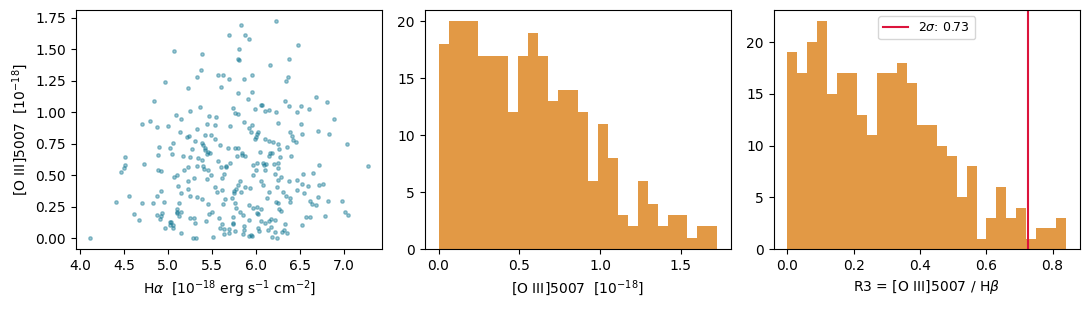

In [6]:
cfg_d = FitConfig.fixed_slope(z=3.193, mc={"method": "posterior", "keep_draws": True})
res_d = fit(phot_cr3, cfg_d)
draws = res_d.posterior_draws
print("draw keys:", sorted(draws))

ha = np.array(draws["Halpha"]) / 1e-18
o3 = np.array(draws["OIII5007"]) / 1e-18
r3d = np.array(draws["R3"])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].scatter(ha, o3, s=6, alpha=0.4, color="#0e7490")
axes[0].set(xlabel=r"H$\alpha$  [$10^{-18}$ erg s$^{-1}$ cm$^{-2}$]",
            ylabel=r"[O III]5007  [$10^{-18}$]")
axes[1].hist(o3, bins=28, color="#d97706", alpha=0.75)
axes[1].set(xlabel=r"[O III]5007  [$10^{-18}$]")
axes[2].hist(r3d, bins=28, color="#d97706", alpha=0.75)
p975 = res_d.ratios[0].value.percentiles.p975
axes[2].axvline(p975, color="crimson", lw=1.5, label=f"2$\sigma$: {p975:.2f}")
axes[2].set(xlabel=r"R3 = [O III]5007 / H$\beta$")
axes[2].legend(fontsize=9)
plt.tight_layout()

## 5. Every role is editable

Switch lines between `free` / `tied` / `off`, change tie ratios, set the Balmer ties from the
Osterbrock & Ferland (2006) tables by recombination case, temperature, and density, or add
[N II]+[S II] as an H$\alpha$-tied contaminant. Configs are immutable — each `with_*` call
returns a validated copy (typos and broken ties raise immediately).

In [7]:
cfg2 = (FitConfig(z=6.203)                             # slope free (grid-searched)
        .with_line_role("HeII4686", "free")            # He II out of the [O III] blend
        .with_balmer(case="A", te=20000.0)             # Case A, hot nebula
        .with_contaminant_mode(0.35))                  # [N II]+[S II] tied to Halpha

for l in cfg2.lines:
    if l.role != "off":
        tie = f"  =  {l.ratio:.4f} x {l.tied_to}" if l.role == "tied" else ""
        print(f"{l.name:11s} {l.role:4s}{tie}")

Halpha      free
Hbeta       tied  =  0.3717 x Halpha
Hgamma      tied  =  0.4850 x Hbeta
Hdelta      tied  =  0.2710 x Hbeta
Hepsilon    tied  =  0.1670 x Hbeta
H8          tied  =  0.1120 x Hbeta
H9          tied  =  0.0785 x Hbeta
H10         tied  =  0.0571 x Hbeta
OIII5007    free
OIII4959    tied  =  0.3356 x OIII5007
HeII4686    free
NII6584     tied  =  0.1167 x Halpha
SII6717     tied  =  0.1167 x Halpha
SII6731     tied  =  0.1167 x Halpha


## 6. A four-band example: GLIMPSE-16043

The $z = 6.203$ source of Fujimoto et al. (2025), using the NIRCam bands with published
fluxes that cover H$\gamma$–He I (Table 5 of the follow-up). F480M carries the strong
H$\alpha$ excess; F410M is the continuum non-detection.

In [8]:
phot_glimpse = {"F356W": (3.08 * NJY, 0.49 * NJY),
                "F410M": (0.78 * NJY, 0.92 * NJY),
                "F444W": (4.07 * NJY, 0.49 * NJY),
                "F480M": (10.95 * NJY, 1.91 * NJY)}

res_g = fit(phot_glimpse, FitConfig.fixed_slope(z=6.20285, mc={"method": "posterior"}))
rg = res_g.ratios[0]
print(f"R3 status: {rg.status};  2-sigma bound: {rg.value.percentiles.p975:.2f}")
print("engine warnings:", res_g.warnings or "none")

R3 status: upper_limit;  2-sigma bound: 1.92
engine warnings: none


## 7. Beyond this notebook

- **Web application** — `lated serve` starts the full interactive workbench at
  `http://127.0.0.1:8321`: the parameter board, literature examples, SED + corner figures with
  PDF export, and a REST API documented at `/docs`.
- **CLI** — `lated fit input.json`, `lated bands`, `lated lines`.
- The default configuration reproduces the LATED Paper I pipeline exactly
  (see `tests/test_parity.py`); the deliberate differences are documented in the README.

If `lated` contributes to your research, please cite **Li et al. (2026, LATED Paper I)**.